# Manually relabel ferPlus emotions

In this file we will manually label emotions that are evenly chosen by the 10 people. 

In [1]:
import pandas as pd
import numpy as np
import csv
from PIL import Image
from matplotlib import pyplot as plt
import os

From this [OneDrive](https://hogeschoolutrecht-my.sharepoint.com/:f:/g/personal/maria_dukmak_student_hu_nl/EmqBJYOP0vlBkooWVJumwPUBP0KgdwxJi7r9xG-n3nbjPA?e=yDvlHq) you can download the 'train.csv' and 'train_relabeled_data.csv'.
Make a folder next to this notebook containing these files. \
If you want to relabel your test files you simply have to do the same but instead you download the test files from the same onedrives and change your paths to the correct ones.

We check if there has already been made a new file named train- or test_hand_relabeled_emotions. In this file we replace the needed emotions with the manually labeled emotion.

In [2]:
#Existent is a variable for later on to see if a certain file was already existing or not.
existent = False

data = pd.read_csv('../../../test_data_lead/ferPlus_data_ready/train.csv')
if os.path.isfile("../../../test_data_lead/ferPlus_data_ready/train_hand_relabeled_emotions.csv"):
    existent = True
    relabeled_data = pd.read_csv('../../../test_data_lead/ferPlus_data_ready/train_hand_relabeled_emotions.csv')
else:
    relabeled_data = pd.read_csv('../../../test_data_lead/ferPlus_data_ready/train_relabeled_data.csv')
data.head(10)
relabeled_data.head()

,neutral,happiness,surprise,sadness,anger,disgust,fear,target,left_of
0,4,0,0,1,3,2,0,neutral,0.0
1,6,0,1,1,0,0,0,neutral,NaN
2,5,0,0,3,1,0,0,neutral,NaN
3,4,0,0,4,1,0,0,sadness,NaN
4,9,0,0,1,0,0,0,neutral,NaN


We define which number belongs to which emotion.

In [3]:
emotions = {'0':'neutral', '1':'happiness', '2':'surprise', 
            '3':'sadness', '4':'anger', '5':'disgust', '6':'fear', '7':'contempt'}

Create a cell where we save the index of the last relabeled image. That way we can continue from the last relabeled image.

In [4]:
data['formatted_pixels'] = ''

if existent == False:
    relabeled_data['left_of'] = ''
    relabeled_data.at[0,'left_of'] = 0

A function for formatting from all pixel strings to a numpy array. After you have reformatted all pixel strings you can plot all images.

In [5]:
def format_pixels(data):
    for index, image_pixels in enumerate(data['pixels']):
        image_string = image_pixels.split(' ')
        image_data = np.asarray(image_string, dtype=np.uint8).reshape(48, 48)
        data.at[index,'formatted_pixels']= image_data

In [6]:
format_pixels(data)

Call the last stayed index after stopping with labeling.

In [7]:
begin = int(relabeled_data['left_of'].iloc[0])

Count how many rows have more than 1 most chosen emotion.

In [8]:
dubble_max_rows = []
tripple_max_rows = []
quadruple_max_rows = []
five_max_rows = []

multiple_max_array = []

maxes = relabeled_data.max(axis=1)

for index in range(begin, len(relabeled_data['neutral'])):
    even_emotions = []
    amount_maxes = 0
    row = relabeled_data.iloc[index]    
    
    for i, x in enumerate(row):
        if x == maxes[index]:
            even_emotions.append(emotions[str(i)])
            amount_maxes += 1
    
    if amount_maxes >= 2:
        dubble_max_rows.append(index)
        multiple_max_array.append(even_emotions)
        
    if amount_maxes >= 3:
        tripple_max_rows.append(index)
        
    if amount_maxes >= 4:
        quadruple_max_rows.append(index)
        
    if amount_maxes >= 5:
        five_max_rows.append(index)
       
print('2 the same: ', len(dubble_max_rows))
print('3 the same: ', len(tripple_max_rows))
print('4 the same: ', len(quadruple_max_rows))
print('5 the same: ', len(five_max_rows))

2 the same:  1240
3 the same:  79
4 the same:  15
5 the same:  1


The following ensures that each image to be relabeled is one by one displayed with the emotions to be chosen from.


Type stop to save it and quit, you can close the file after it says pprocess finished. Otherwise you can choose the number of the emotion, the first in the list is 0, and the second in the list is 1. You enter these numbers and the correct emotion will be chosen automatically.

index number:  3
['neutral', 'sadness']


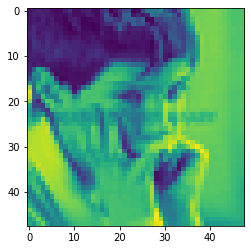

What is the emotion: 1


chosen before:  sadness
index number:  24
['neutral', 'surprise']


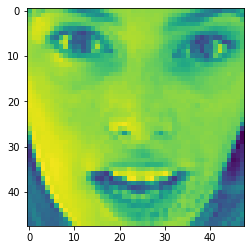

What is the emotion: stop


process finished


In [9]:
for index, row_index in enumerate(dubble_max_rows):
    row = data.iloc[row_index]
    
    image = row['formatted_pixels']
    img = Image.fromarray(image)
    imgplot = plt.imshow(img)
    
    print('index number: ', row_index)
    print(multiple_max_array[index])
    plt.show()
    
    chosen_emotion = ''
    
    while chosen_emotion not in emotions and chosen_emotion != 'stop':   
        chosen_emotion = input('What is the emotion: ')
    print('\n')
    
    if chosen_emotion == 'stop': 
        relabeled_data.at[0,'left_of'] = row_index
        break
    else:
        relabeled_data.at[row_index,'target'] = multiple_max_array[index][int(chosen_emotion)]
        print('chosen before: ', multiple_max_array[index][int(chosen_emotion)])
        
relabeled_data.to_csv("../../../test_data_lead/ferPlus_data_ready/train_hand_relabeled_emotions.csv", index=False)
print('process finished')